In [1]:
!pip install praw pandas matplotlib 

In [2]:
import pandas as pd
import sys
import json
import string
from collections import Counter
import nltk
import re
import html
#for messy text in comments, helps removes non-lexicon data for cleaner analysis
from nltk.tokenize import TweetTokenizer
tokenizer = TweetTokenizer()

from nltk.stem import PorterStemmer
stemmer = PorterStemmer()

nltk.download('stopwords')
import matplotlib.pyplot as mpl



[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/forsc1/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [3]:
#Function to pre-process reddit data

def processText(text, tokenizer, stemmer, stopwords):

    text = text.lower()
    text = re.sub(r"http\S+", "", text)
    
    lTokens = tokenizer.tokenize(text)
    lTokens = [token.strip() for token in lTokens]

    #removing stop words before stemming
    lTokens = [tok for tok in lTokens if tok not in stopwords and not tok.isdigit()]

    lStemmedTokens = [stemmer.stem(tok) for tok in lTokens]
    
    return lStemmedTokens

    

In [4]:
#doing tokenization stopword removal and stemming to furher clean the data

fJsonName = "rawComments.json"
dfComments = pd.read_json("rawComments.json")

#removing deleted and duplicated comments
dfComments = dfComments.dropna(subset=["body"])
dfComments = dfComments[~dfComments["body"].isin(["[deleted]", "[removed]"])]

wordFrequency = 50

lPunct = list(string.punctuation)
lStopwords = nltk.corpus.stopwords.words('english') + lPunct + ['via', 'http', 'https', 'www',]

wordFreqCounter = Counter()

cleanComments = []

for comment in dfComments["body"]:

    lTokens = processText(
        text=str(comment),
        stopwords=lStopwords,
        tokenizer=tokenizer,
        stemmer=stemmer,
    )

    wordFreqCounter.update(lTokens)

    cleanComment = " ".join(lTokens)
    cleanComments.append(cleanComment)

#adding cleaned column
dfComments["cleanBody"] = cleanComments

#saving cleaned data
dfComments.to_json("cleanComments.json", orient="records")

#printing the most common words to check pre-processing worked
for word, count in wordFreqCounter.most_common(wordFrequency):
    print(word + ': ' + str(count)) 


china: 2536
us: 1254
peopl: 1160
would: 1013
countri: 949
like: 926
russia: 890
sanction: 756
get: 662
one: 626
want: 604
think: 593
go: 559
make: 546
world: 537
govern: 524
even: 522
war: 505
state: 498
say: 480
also: 464
chines: 454
year: 447
much: 443
korea: 440
...: 418
oil: 411
know: 399
use: 398
time: 396
north: 385
thing: 381
power: 379
way: 370
nation: 353
take: 349
see: 348
good: 346
need: 346
american: 345
right: 340
work: 335
still: 332
well: 325
realli: 321
that': 319
could: 304
point: 300
america: 298
look: 295


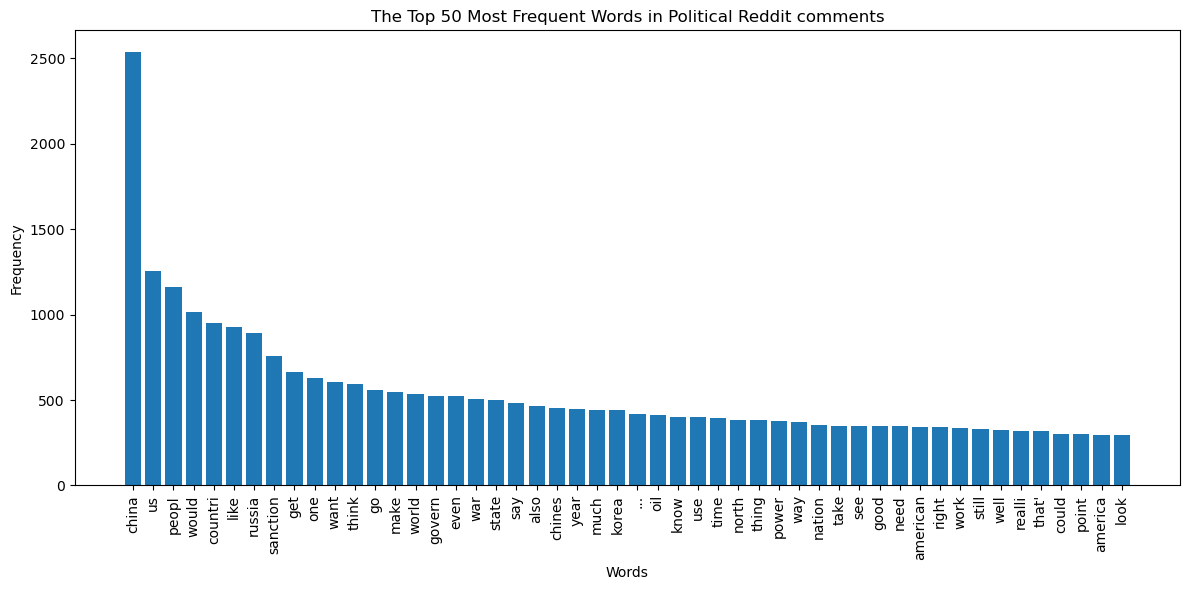

In [5]:
#Data graph for more frequent terms 
words = []
counts = []

for word, count in wordFreqCounter.most_common(wordFrequency):
    words.append(word)
    counts.append(count)

mpl.figure(figsize=(12, 6))
mpl.bar(words, counts)
mpl.xticks(rotation=90)
mpl.title("The Top 50 Most Frequent Words in Political Reddit comments")
mpl.xlabel("Words")
mpl.ylabel("Frequency")
mpl.tight_layout()
mpl.show()
